## 0. Setup & Imports

Load libraries and set constants.

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import joblib, json, os, warnings
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import (
    RandomForestRegressor, HistGradientBoostingRegressor,
    VotingRegressor, StackingRegressor,
)
from sklearn.linear_model import RidgeCV
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Style
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.35,
})
PALETTE = ["#2ecc71","#3498db","#9b59b6","#e67e22","#e74c3c",
           "#1abc9c","#f39c12","#2980b9","#8e44ad"]
print("Libraries loaded.")


Libraries loaded.


## 1. Data Loading

In [70]:
DATA_PATH = Path("../data/bps_2024_model_ready2.csv")
df = pd.read_csv(DATA_PATH)
print("Loaded shape:", df.shape)
print("Columns:", list(df.columns))


Loaded shape: (10280, 13)
Columns: ['Sector', 'Subsector', 'Primary Property Type - Self Selected', 'Largest Property Use Type', 'Property GFA - Self-Reported (m²)', 'Number of Buildings', 'Electricity Use - Grid Purchase (GJ)', 'Natural Gas Use (GJ)', 'Other_Fuels_GJ', 'District_Energy_GJ', 'Has_NaturalGas', 'Has_Electricity', 'Total (Location-Based) GHG Emissions (Metric Tons CO2e)']


## 2. Target & Feature Overview

In [71]:
TARGET = "Total (Location-Based) GHG Emissions (Metric Tons CO2e)"
df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")

desc = df[TARGET].describe(percentiles=[0.9, 0.95, 0.99]).round(4)
display(desc)

zero_rate = (df[TARGET] == 0).mean() * 100
print(f"Zero-target rate: {zero_rate:.2f}%")

print("\nData types:")
print(df.dtypes.value_counts())

print("\nTop missing columns (%):")
missing_pct = df.isna().mean().sort_values(ascending=False).mul(100).round(2)
display(missing_pct.head(10))


count    10280.0000
mean       142.0922
std        795.9624
min          0.0000
50%         10.8800
90%        213.0880
95%        494.4230
99%       2334.7069
max      22213.1600
Name: Total (Location-Based) GHG Emissions (Metric Tons CO2e), dtype: float64

Zero-target rate: 2.54%

Data types:
float64    6
object     4
int64      3
Name: count, dtype: int64

Top missing columns (%):


Natural Gas Use (GJ)                     43.60
Electricity Use - Grid Purchase (GJ)      3.22
Largest Property Use Type                 0.06
Sector                                    0.00
Subsector                                 0.00
Property GFA - Self-Reported (m²)         0.00
Primary Property Type - Self Selected     0.00
Number of Buildings                       0.00
Other_Fuels_GJ                            0.00
District_Energy_GJ                        0.00
dtype: float64

## 3. Train / Test Split

In [72]:
CAT_COLS      = ["Sector", "Subsector",
                 "Primary Property Type - Self Selected",
                 "Largest Property Use Type"]
ENERGY_COLS   = ["Electricity Use - Grid Purchase (GJ)",
                 "Natural Gas Use (GJ)", "Other_Fuels_GJ", "District_Energy_GJ"]
OTHER_NUM_COLS= ["Property GFA - Self-Reported (m²)", "Number of Buildings"]
INDICATOR_COLS= ["Has_NaturalGas", "Has_Electricity"]

cat_cols      = [c for c in CAT_COLS       if c in df.columns]
energy_cols   = [c for c in ENERGY_COLS     if c in df.columns]
other_num_cols= [c for c in OTHER_NUM_COLS  if c in df.columns]
indicator_cols= [c for c in INDICATOR_COLS  if c in df.columns]

feature_cols = cat_cols + other_num_cols + indicator_cols

X = df[feature_cols].copy()
y = df[TARGET].copy()

y_bins = pd.qcut(y, q=10, duplicates="drop")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y_bins
)

print("Train shape:", X_train.shape)
print("Test  shape:", X_test.shape)


Train shape: (8224, 8)
Test  shape: (2056, 8)


## 4. Preprocessing Pipeline

In [73]:
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

cat_pipe      = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                           ("onehot", ohe)])
other_num_pipe= Pipeline([("imputer", SimpleImputer(strategy="median"))])

preprocess    = ColumnTransformer([
    ("cat", cat_pipe, cat_cols),
    ("num", other_num_pipe, other_num_cols + indicator_cols),
], remainder="drop")

print("Preprocessing pipeline built.")


Preprocessing pipeline built.


## 5. Evaluation Helper

In [74]:
def evaluate_regression(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)
    return {
        "MAE":  mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2":   r2_score(y_true, y_pred),
    }


## 6. Baseline Models

In [75]:
baseline_mean   = Pipeline([("preprocess", preprocess),
                             ("model", DummyRegressor(strategy="mean"))])
baseline_median = Pipeline([("preprocess", preprocess),
                             ("model", DummyRegressor(strategy="median"))])

baseline_mean.fit(X_train, y_train)
m_mean   = evaluate_regression(y_test, baseline_mean.predict(X_test))

baseline_median.fit(X_train, y_train)
m_median = evaluate_regression(y_test, baseline_median.predict(X_test))

print("Baseline (Mean):", m_mean)
print("Baseline (Median):", m_median)


Baseline (Mean): {'MAE': 203.6232916542075, 'RMSE': np.float64(695.6436967618702), 'R2': -0.0005667983909283247}
Baseline (Median): {'MAE': 125.8828939688716, 'RMSE': np.float64(705.3808731773258), 'R2': -0.02877342627481294}


## 7. Linear Models

In [76]:
lin_reg = Pipeline([("preprocess", preprocess),
                     ("model", LinearRegression())])
ridge   = Pipeline([("preprocess", preprocess),
                     ("model", Ridge(alpha=1.0))])

lin_reg.fit(X_train, y_train)
m_lin   = evaluate_regression(y_test, lin_reg.predict(X_test))

ridge.fit(X_train, y_train)
m_ridge = evaluate_regression(y_test, ridge.predict(X_test))

results = pd.DataFrame([
    {"Model": "DummyMean",        **m_mean},
    {"Model": "DummyMedian",      **m_median},
    {"Model": "LinearRegression", **m_lin},
    {"Model": "Ridge(alpha=1.0)", **m_ridge},
]).sort_values("RMSE")

display(results)


,Model,MAE,RMSE,R2
3,Ridge(alpha=1.0),148.945218,557.471692,0.357434
2,LinearRegression,150.127905,559.643489,0.352417
0,DummyMean,203.623292,695.643697,-0.000567
1,DummyMedian,125.882894,705.380873,-0.028773


## 8. Advanced Tree-Based Models

In [77]:
rf   = Pipeline([("preprocess", preprocess),
                  ("model", RandomForestRegressor(
                      n_estimators=100, max_features=0.5,
                      random_state=RANDOM_STATE, n_jobs=-1))])
hgbr = Pipeline([("preprocess", preprocess),
                  ("model", HistGradientBoostingRegressor(
                      max_iter=300, learning_rate=0.05,
                      max_leaf_nodes=31, random_state=RANDOM_STATE))])
xgb  = Pipeline([("preprocess", preprocess),
                  ("model", XGBRegressor(
                      n_estimators=300, learning_rate=0.05,
                      max_depth=6, random_state=RANDOM_STATE, n_jobs=-1))])

print("Training RandomForest...")
rf.fit(X_train, y_train)
m_rf   = evaluate_regression(y_test, rf.predict(X_test))

print("Training HistGradientBoosting...")
hgbr.fit(X_train, y_train)
m_hgbr = evaluate_regression(y_test, hgbr.predict(X_test))

print("Training XGBoost...")
xgb.fit(X_train, y_train)
m_xgb  = evaluate_regression(y_test, xgb.predict(X_test))

adv_results = pd.DataFrame([
    {"Model": "RandomForest",        **m_rf},
    {"Model": "HistGradientBoosting",**m_hgbr},
    {"Model": "XGBoost",             **m_xgb},
])
results = (pd.concat([results, adv_results])
              .sort_values("RMSE")
              .reset_index(drop=True))
display(results)


Training RandomForest...
Training HistGradientBoosting...
Training XGBoost...


,Model,MAE,RMSE,R2
0,RandomForest,62.518433,245.524614,0.875359
1,HistGradientBoosting,65.302308,246.032799,0.874842
2,XGBoost,68.935170,392.746218,0.681069
3,Ridge(alpha=1.0),148.945218,557.471692,0.357434
4,LinearRegression,150.127905,559.643489,0.352417
5,DummyMean,203.623292,695.643697,-0.000567
6,DummyMedian,125.882894,705.380873,-0.028773


## 9. Ensemble Methods

In [78]:
print("Training Voting Regressor...")
voting_ens = VotingRegressor(
    estimators=[("rf", rf), ("hgbr", hgbr), ("xgb", xgb)],
    n_jobs=-1
)
voting_ens.fit(X_train, y_train)
m_voting = evaluate_regression(y_test, voting_ens.predict(X_test))

print("Training Stacking Regressor...")
stacking_ens = StackingRegressor(
    estimators=[("rf", rf), ("hgbr", hgbr), ("xgb", xgb)],
    final_estimator=RidgeCV(),
    cv=3, n_jobs=-1
)
stacking_ens.fit(X_train, y_train)
m_stacking = evaluate_regression(y_test, stacking_ens.predict(X_test))

ens_res = pd.DataFrame([
    {"Model": "VotingEnsemble",   **m_voting},
    {"Model": "StackingEnsemble", **m_stacking},
])
results = (pd.concat([results, ens_res], ignore_index=True)
              .drop_duplicates(subset=["Model"], keep="last")
              .sort_values("RMSE")
              .reset_index(drop=True))

print("\n=== FINAL RESULTS (sorted by RMSE) ===")
display(results)


Training Voting Regressor...
Training Stacking Regressor...

=== FINAL RESULTS (sorted by RMSE) ===


,Model,MAE,RMSE,R2
0,VotingEnsemble,60.517781,231.431528,0.889257
1,RandomForest,62.518433,245.524614,0.875359
2,HistGradientBoosting,65.302308,246.032799,0.874842
3,StackingEnsemble,63.222859,252.307602,0.868377
4,XGBoost,68.935170,392.746218,0.681069
5,Ridge(alpha=1.0),148.945218,557.471692,0.357434
6,LinearRegression,150.127905,559.643489,0.352417
7,DummyMean,203.623292,695.643697,-0.000567
8,DummyMedian,125.882894,705.380873,-0.028773


## 10. Visualizations for Report

### 10a. Model Comparison – MAE, RMSE, R²

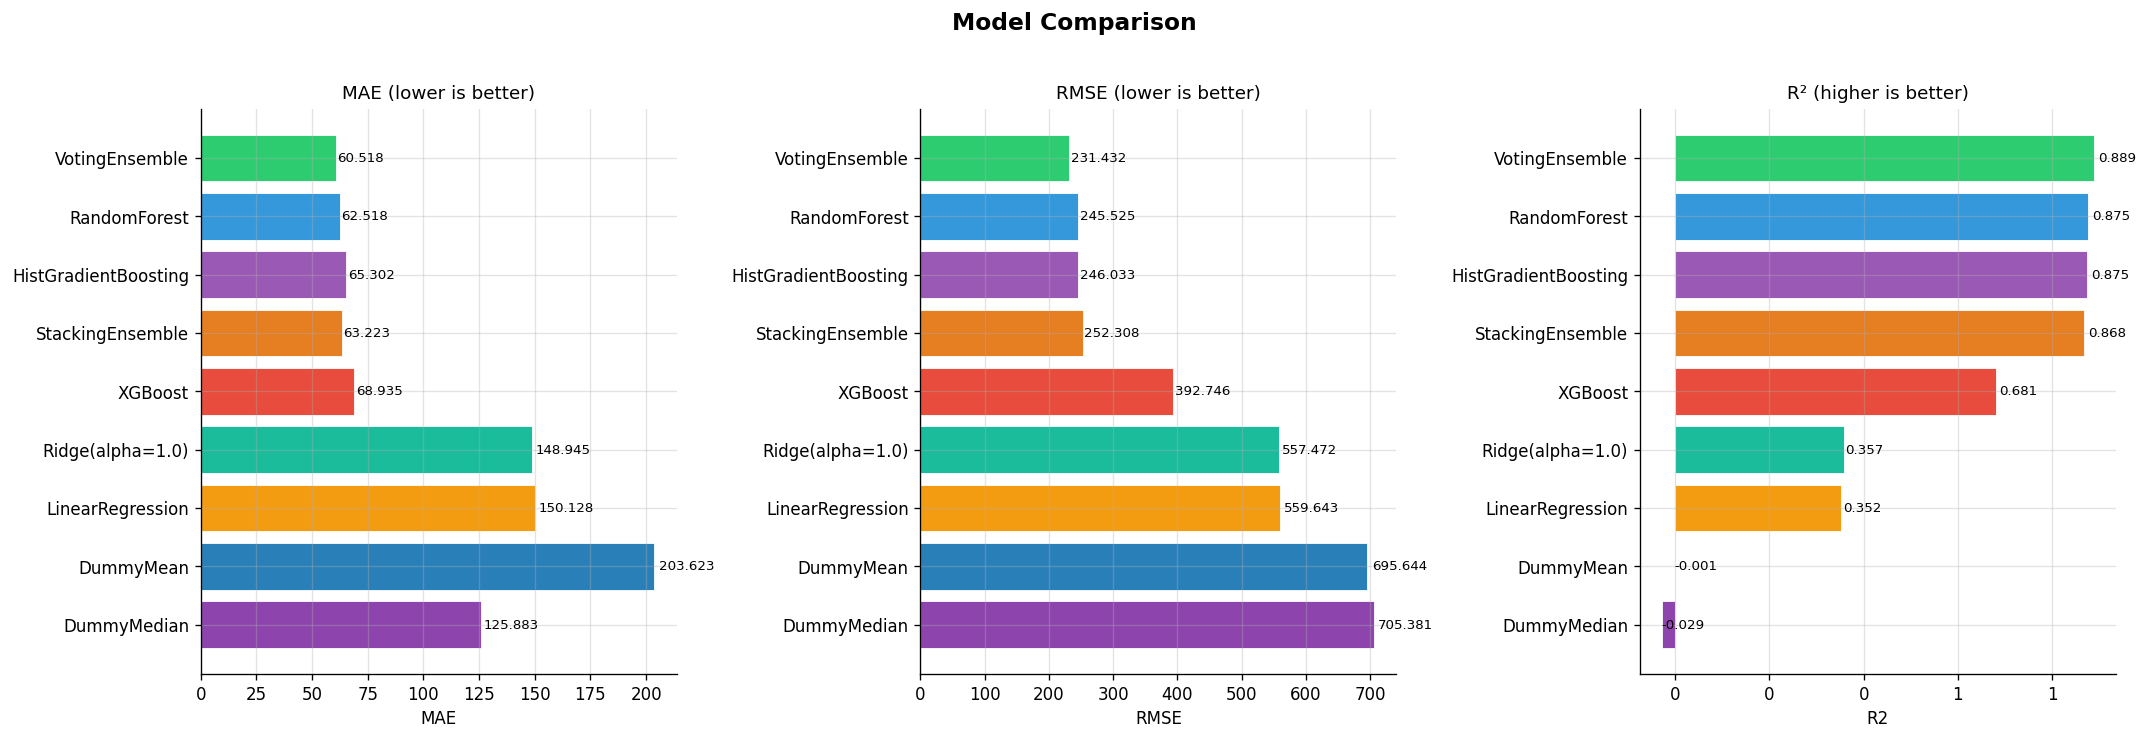

Saved model_comparison_bar.png


In [79]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Model Comparison", fontsize=14, fontweight="bold", y=1.02)

metrics   = ["MAE", "RMSE", "R2"]
titles    = ["MAE (lower is better)", "RMSE (lower is better)", "R² (higher is better)"]
colors    = PALETTE[:len(results)]

for ax, metric, title in zip(axes, metrics, titles):
    bars = ax.barh(results["Model"][::-1], results[metric][::-1],
                   color=colors[::-1], edgecolor="white", linewidth=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(metric)
    for bar, val in zip(bars, results[metric][::-1]):
        ax.text(bar.get_width() + bar.get_width() * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=8)
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.0f"))

plt.tight_layout()
plt.savefig("../outputs/tables/model_comparison_bar.png", bbox_inches="tight")
plt.show()
print("Saved model_comparison_bar.png")


### 10b. Grouped Bar Chart (normalised metrics)

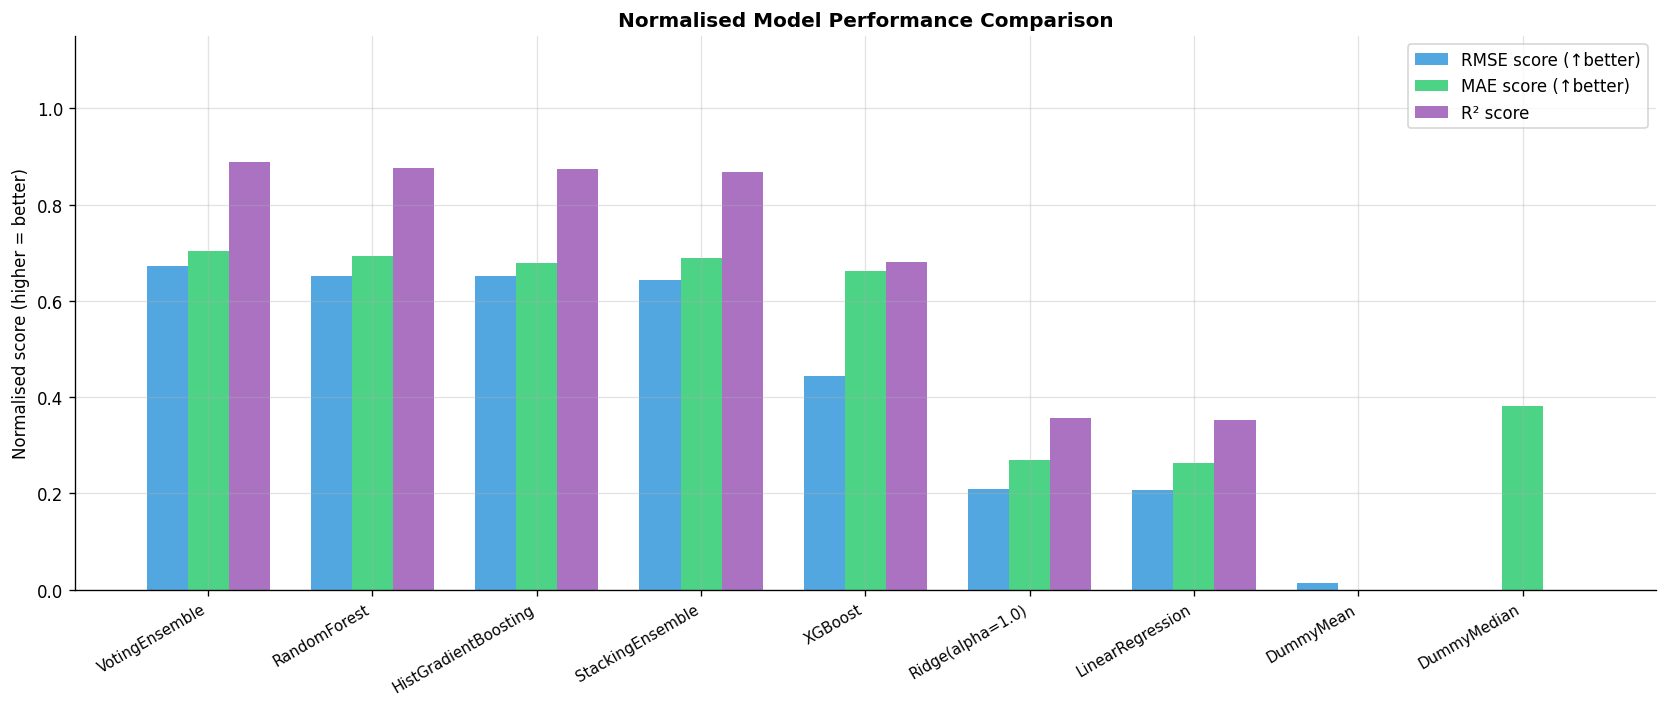

Saved model_comparison_grouped.png


In [80]:
norm = results.copy()
# Normalise so all metrics are in [0,1]: MAE & RMSE = 1 - (val/max), R2 stays
norm["MAE_n"]  = 1 - norm["MAE"]  / norm["MAE"].max()
norm["RMSE_n"] = 1 - norm["RMSE"] / norm["RMSE"].max()
norm["R2_n"]   = norm["R2"].clip(0)       # already [0,1]

x      = np.arange(len(norm))
width  = 0.25
fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(x - width, norm["RMSE_n"], width, label="RMSE score (↑better)", color="#3498db", alpha=0.85)
ax.bar(x,         norm["MAE_n"],  width, label="MAE score (↑better)",  color="#2ecc71", alpha=0.85)
ax.bar(x + width, norm["R2_n"],   width, label="R² score",              color="#9b59b6", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(norm["Model"], rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Normalised score (higher = better)")
ax.set_title("Normalised Model Performance Comparison", fontsize=12, fontweight="bold")
ax.legend()
ax.set_ylim(0, 1.15)

plt.tight_layout()
plt.savefig("../outputs/tables/model_comparison_grouped.png", bbox_inches="tight")
plt.show()
print("Saved model_comparison_grouped.png")


### 10c. Predicted vs Actual & Residual Plot – VotingEnsemble (Best Model)

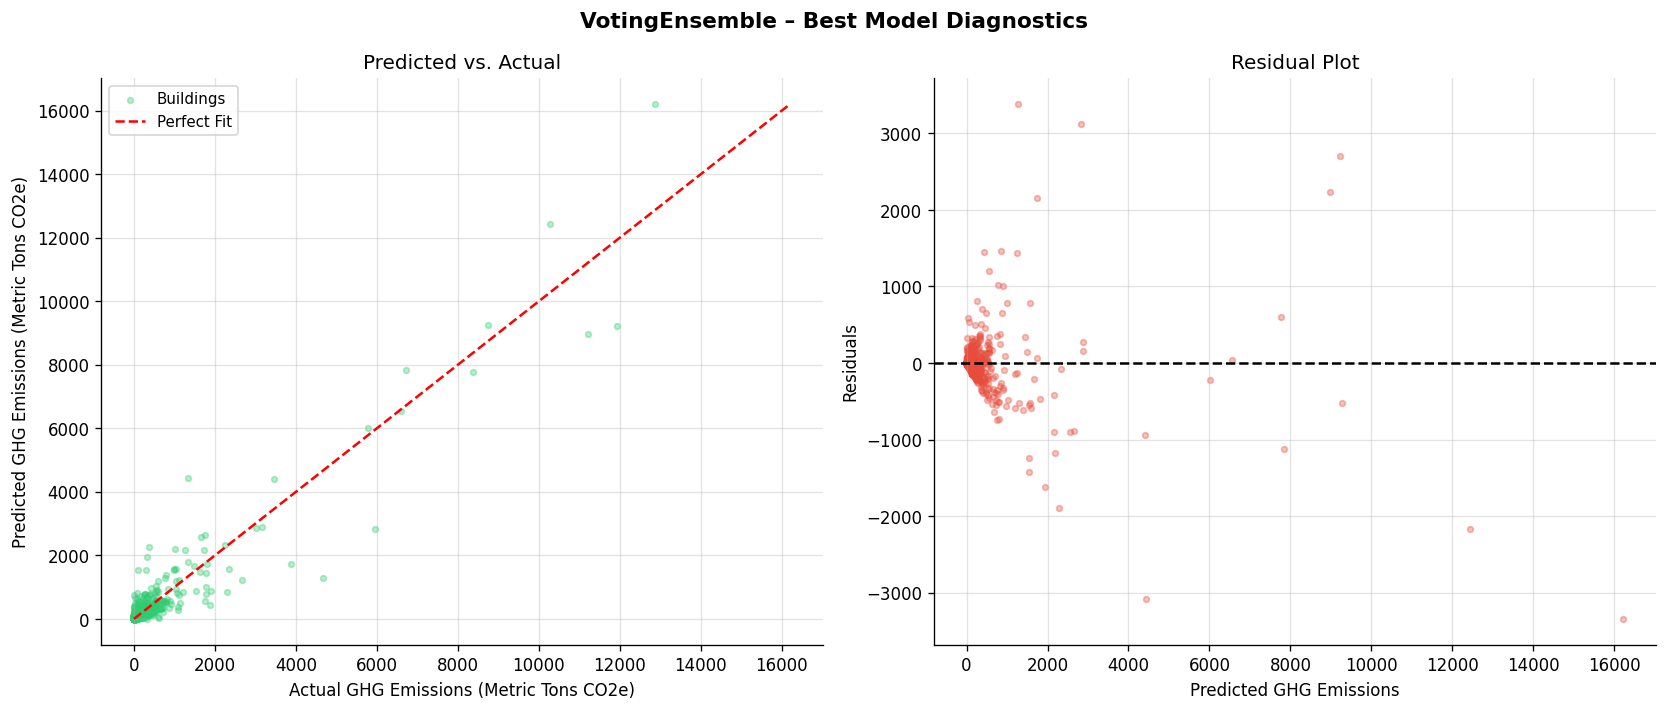

Saved voting_diagnostics.png


In [81]:
pred_best = np.clip(voting_ens.predict(X_test), 0, None)
residuals = y_test.values - pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("VotingEnsemble – Best Model Diagnostics", fontsize=13, fontweight="bold")

# Predicted vs Actual
ax = axes[0]
ax.scatter(y_test, pred_best, alpha=0.35, s=12, color="#2ecc71", label="Buildings")
max_val = max(y_test.max(), pred_best.max())
ax.plot([0, max_val], [0, max_val], "r--", lw=1.5, label="Perfect Fit")
ax.set_xlabel("Actual GHG Emissions (Metric Tons CO2e)")
ax.set_ylabel("Predicted GHG Emissions (Metric Tons CO2e)")
ax.set_title("Predicted vs. Actual")
ax.legend(fontsize=9)

# Residuals
ax = axes[1]
ax.scatter(pred_best, residuals, alpha=0.35, s=12, color="#e74c3c")
ax.axhline(0, color="k", linestyle="--", lw=1.5)
ax.set_xlabel("Predicted GHG Emissions")
ax.set_ylabel("Residuals")
ax.set_title("Residual Plot")

plt.tight_layout()
plt.savefig("../outputs/tables/voting_diagnostics.png", bbox_inches="tight")
plt.show()
print("Saved voting_diagnostics.png")


### 10d. Predicted vs Actual – Coloured by Sector

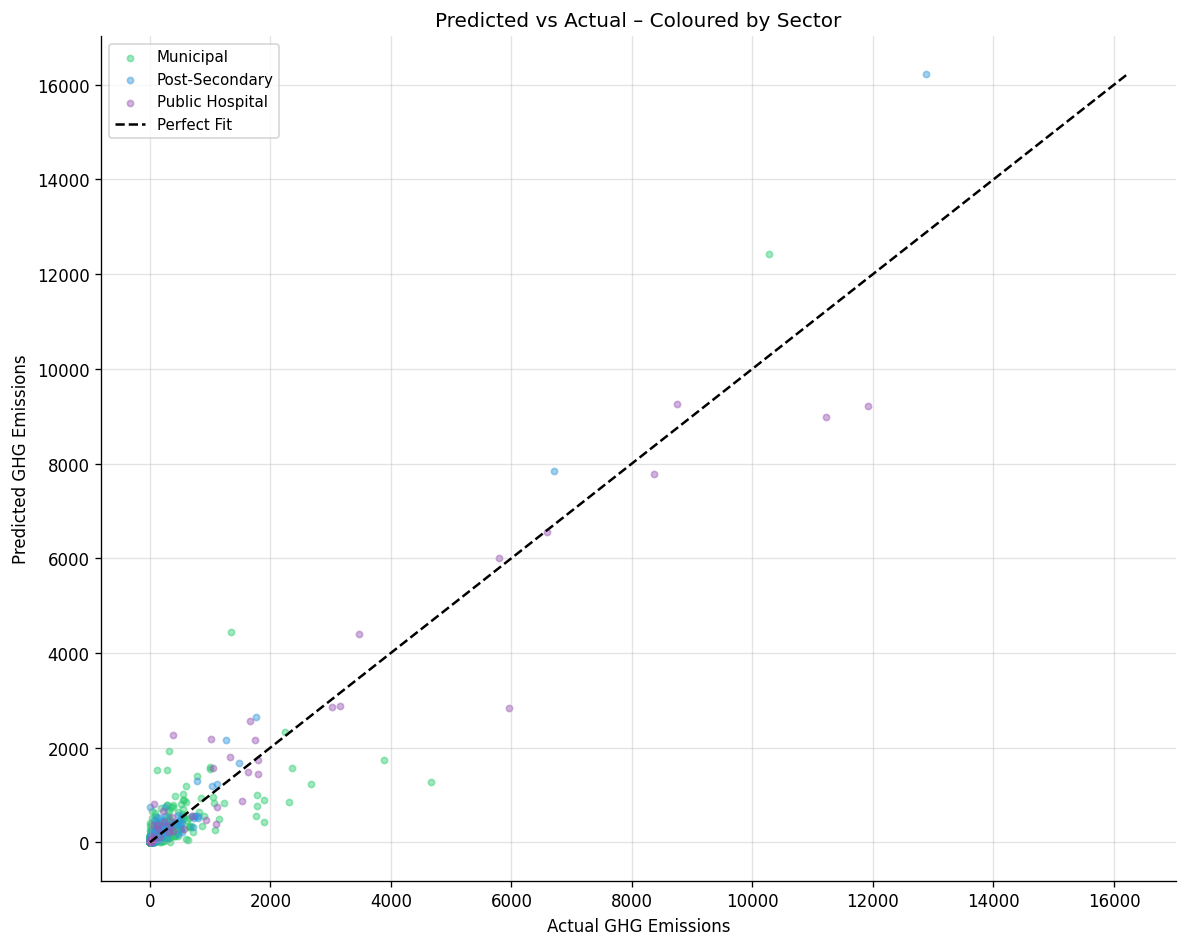

Saved sector_scatter.png


In [82]:
if "Sector" in X_test.columns:
    sectors  = X_test["Sector"].reset_index(drop=True)
    unique_s = sectors.unique()
    cmap     = {s: PALETTE[i % len(PALETTE)] for i, s in enumerate(unique_s)}

    fig, ax  = plt.subplots(figsize=(10, 8))
    for sector in unique_s:
        mask = sectors == sector
        ax.scatter(
            y_test.values[mask], pred_best[mask],
            alpha=0.45, s=14, label=sector,
            color=cmap[sector]
        )

    max_val = max(y_test.max(), pred_best.max())
    ax.plot([0, max_val], [0, max_val], "k--", lw=1.5, label="Perfect Fit")
    ax.set_xlabel("Actual GHG Emissions")
    ax.set_ylabel("Predicted GHG Emissions")
    ax.set_title("Predicted vs Actual – Coloured by Sector")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig("../outputs/tables/sector_scatter.png", bbox_inches="tight")
    plt.show()
    print("Saved sector_scatter.png")
else:
    print("Sector column not present in X_test; skipping sector scatter plot.")


### 10e. Feature Importances (Random Forest sub-model)

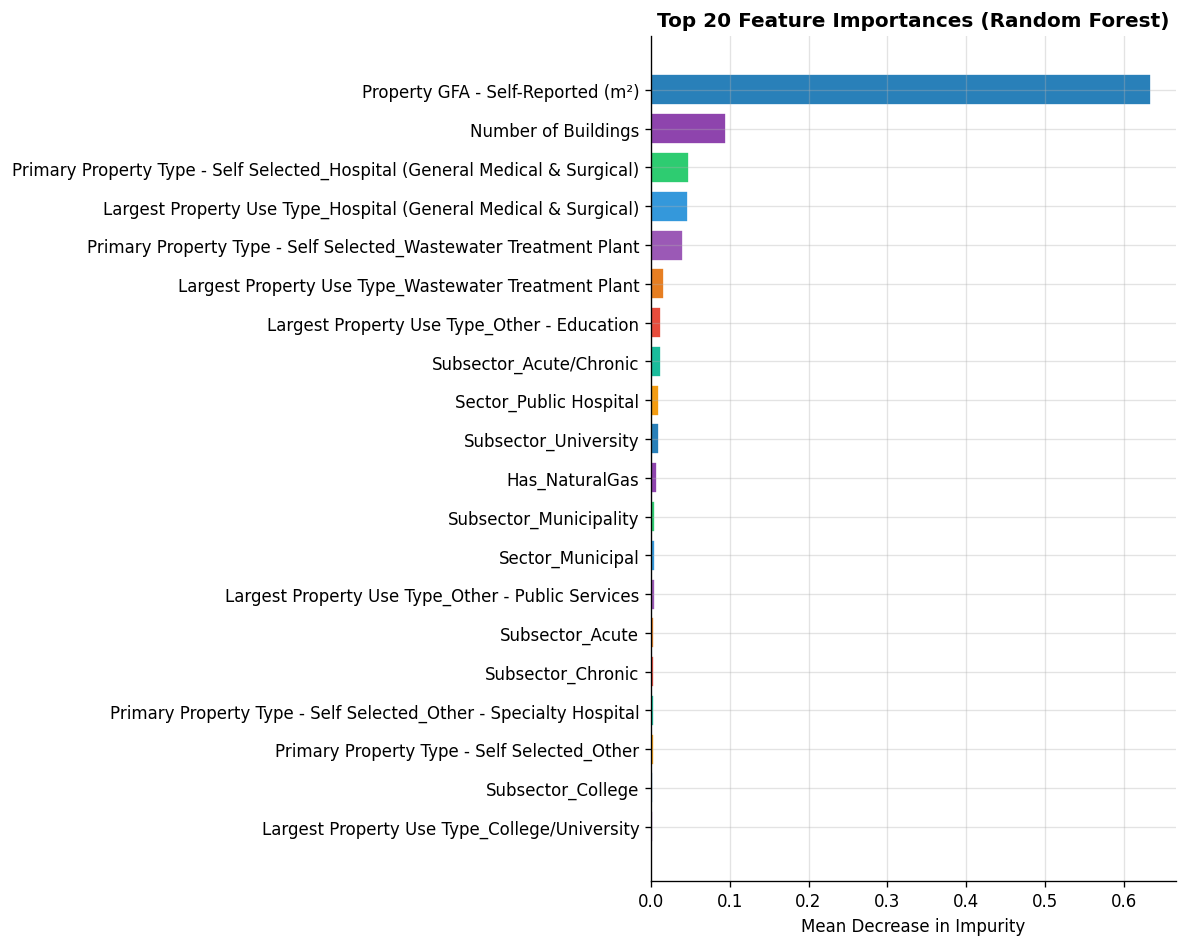

Saved feature_importances.png


In [83]:
# Get feature names from the ColumnTransformer
rf_pipeline    = rf
preprocessor   = rf_pipeline.named_steps["preprocess"]
rf_model       = rf_pipeline.named_steps["model"]

# One-hot encoded names
ohe_names = list(preprocessor.named_transformers_["cat"]
                     .named_steps["onehot"]
                     .get_feature_names_out(cat_cols))
num_names  = other_num_cols + indicator_cols
all_names  = ohe_names + num_names

importances    = rf_model.feature_importances_
feat_imp_df    = (pd.DataFrame({"Feature": all_names, "Importance": importances})
                    .sort_values("Importance", ascending=False)
                    .head(20))

fig, ax = plt.subplots(figsize=(10, 8))
colors  = PALETTE[:20] if len(feat_imp_df) <= 20 else PALETTE * 4
ax.barh(feat_imp_df["Feature"][::-1], feat_imp_df["Importance"][::-1],
        color=colors[:len(feat_imp_df)][::-1], edgecolor="white")
ax.set_xlabel("Mean Decrease in Impurity")
ax.set_title("Top 20 Feature Importances (Random Forest)", fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/tables/feature_importances.png", bbox_inches="tight")
plt.show()
print("Saved feature_importances.png")


### 10f. Prediction Error Distribution – VotingEnsemble

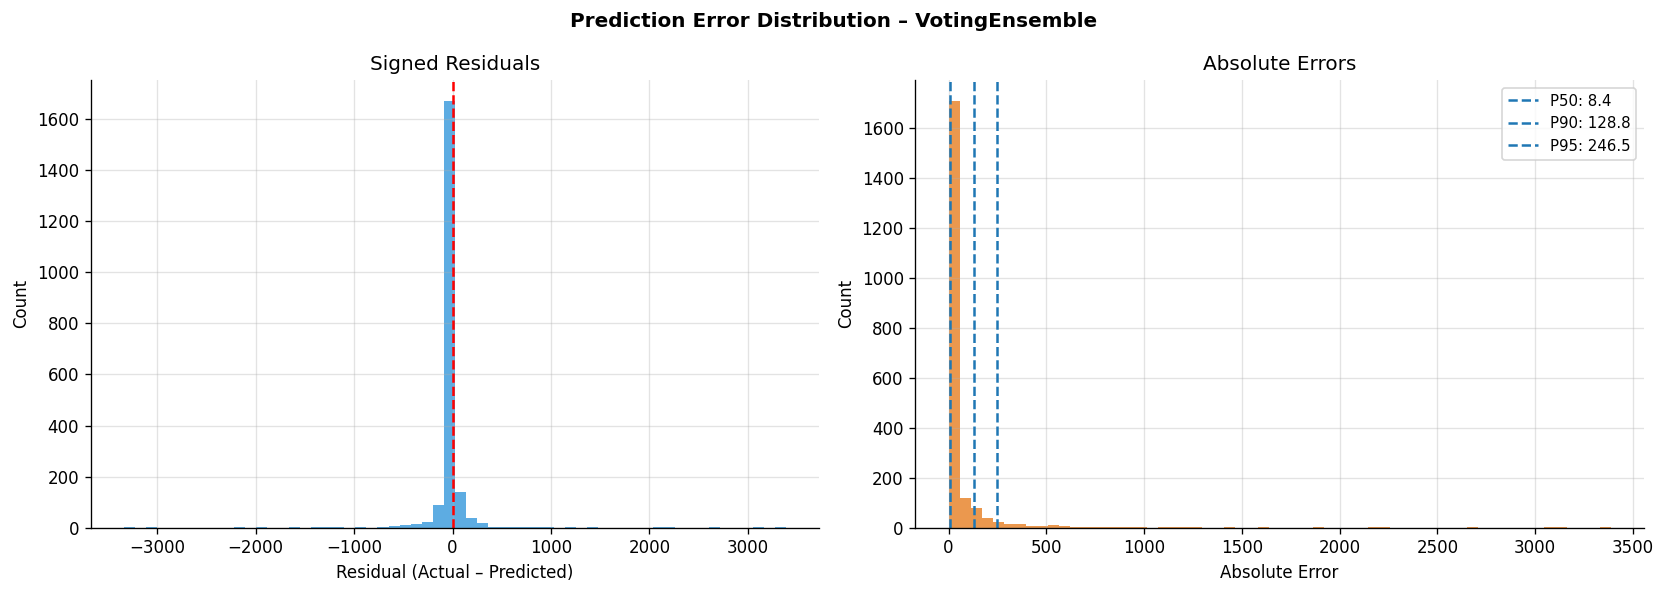

Median AE: 8.44  |  P90 AE: 128.79  |  P95 AE: 246.47


In [84]:
abs_errors = np.abs(residuals)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Prediction Error Distribution – VotingEnsemble", fontweight="bold")

axes[0].hist(residuals, bins=60, color="#3498db", edgecolor="none", alpha=0.8)
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_xlabel("Residual (Actual – Predicted)")
axes[0].set_ylabel("Count")
axes[0].set_title("Signed Residuals")

axes[1].hist(abs_errors, bins=60, color="#e67e22", edgecolor="none", alpha=0.8)
p50, p90, p95 = np.percentile(abs_errors, [50, 90, 95])
for pct, lbl in zip([p50, p90, p95], ["P50", "P90", "P95"]):
    axes[1].axvline(pct, linestyle="--", label=f"{lbl}: {pct:.1f}")
axes[1].set_xlabel("Absolute Error")
axes[1].set_ylabel("Count")
axes[1].set_title("Absolute Errors")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/tables/error_distribution.png", bbox_inches="tight")
plt.show()
print(f"Median AE: {p50:.2f}  |  P90 AE: {p90:.2f}  |  P95 AE: {p95:.2f}")


## 11. Save Best Model for App

Save the VotingEnsemble pipeline so `app.py` can load it.

In [85]:
    import joblib, json
    from pathlib import Path

    OUTPUT_DIR = Path("../outputs/models")
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    # 1. Save the pipeline (preprocessing + VotingEnsemble)
    MODEL_PATH = OUTPUT_DIR / "best_model_pipeline.joblib"
    joblib.dump(voting_ens, MODEL_PATH)
    print(f"Saved best model to {MODEL_PATH}")

    # 2. Save feature schema (used by app.py to validate input CSVs)
    schema = {col: str(X_train[col].dtype) for col in feature_cols}
    SCHEMA_PATH = OUTPUT_DIR / "feature_schema.json"
    with open(SCHEMA_PATH, "w") as f:
        json.dump(schema, f, indent=2)
    print(f"Saved feature schema to {SCHEMA_PATH}")

    # 3. Write / update model card
    best_row = results.loc[results["Model"] == "VotingEnsemble"].iloc[0]
    card = f"""# Model Card – GHG Emissions Predictor

## Model
VotingEnsemble (RandomForest + HistGradientBoosting + XGBoost)

## Performance on Test Set
| Metric | Value |
|--------|-------|
| MAE    | {best_row['MAE']:.4f} |
| RMSE   | {best_row['RMSE']:.4f} |
| R²     | {best_row['R2']:.6f} |

## Training Data
- Dataset: BPS 2024 (buildings energy & GHG)
- Target: Total (Location-Based) GHG Emissions (Metric Tons CO2e)
- Train / Test split: 80 / 20 (stratified quantile bins)

## Features
{json.dumps(schema, indent=2)}

## Notes
- Sub-estimators: RandomForest (100 trees), HistGradientBoosting (300 iters), XGBoost (300 rounds)
- Preprocessing inside each sub-pipeline: OHE for categoricals, median imputation for numerics
"""
    CARD_PATH = OUTPUT_DIR / "model_card.md"
    CARD_PATH.write_text(card)
    print(f"Saved model card to {CARD_PATH}")
    print("\n=== Done! Best model saved. ===")


Saved best model to ../outputs/models/best_model_pipeline.joblib
Saved feature schema to ../outputs/models/feature_schema.json
Saved model card to ../outputs/models/model_card.md

=== Done! Best model saved. ===
